## Brexit tweet analysis for 2016
In this assignment you will analyse a dataset that contains Brexit tweet and retweet data from 2016.

#### Q1. Import the data file "brexit_tweet_count_by_data.csv" into a Pandas DataFrame object. The data contains two entries for each date corresponding to tweets (``retweet = False``) and retweets (``retweet=True``). Pivot the data so that each date is on a single row and with separate columns for tweets and retweets.

In [2]:
import pandas as pd
df = pd.read_csv("brexit_tweet_count_by_data.csv")
print(df.head(5))

# pivoting data so true and false turns into tweets and retweets
pivot_df = df.pivot(index="date", columns="retweet", values="total_count")
pivot_df.columns = ['tweets', 'retweets']  
pivot_df = pivot_df.reset_index()

print(pivot_df.head())

         date  retweet  total_count
0  2016-01-06     True         1942
1  2016-01-06    False          699
2  2016-01-07    False         3511
3  2016-01-07     True         4811
4  2016-01-08     True         4752
         date  tweets  retweets
0  2016-01-06     699      1942
1  2016-01-07    3511      4811
2  2016-01-08    2401      4752
3  2016-01-09    1620      4193
4  2016-01-10    2744      5038


#### Q2. Import the plotting library and plot the tweet and retweet data as two separate time series in the same plot. You may use the following plotting code as a starting point.

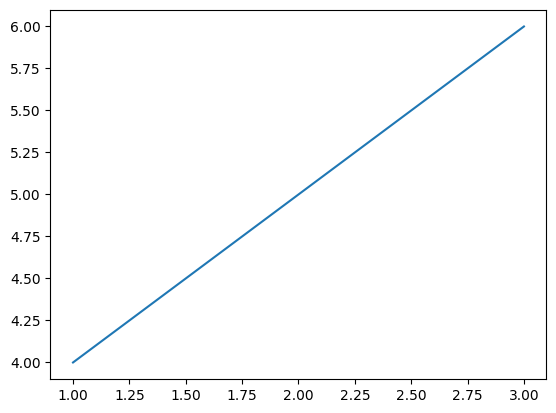

In [1]:
#test matplotlib
#%matplotlib inline
#import matplotlib.pyplot as plt

#plt.plot([1, 2, 3], [4, 5, 6])

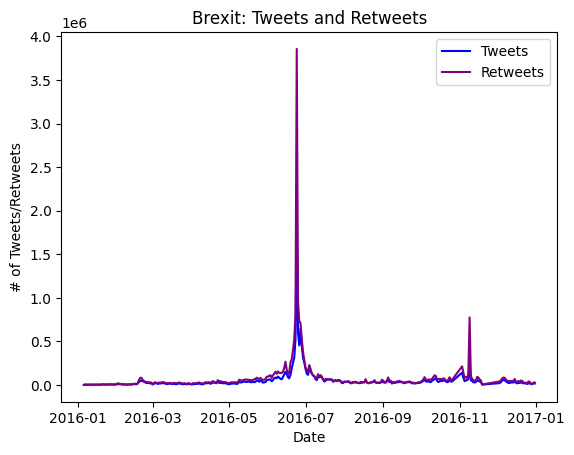

In [3]:
import matplotlib.pyplot as plt

pivot_df['date'] = pd.to_datetime(pivot_df['date'])

#plotting tweets and retweets in diff colors on same graph
plt.plot(pivot_df['date'], pivot_df['tweets'], label='Tweets', color='blue')
plt.plot(pivot_df['date'], pivot_df['retweets'], label='Retweets', color='purple')

plt.title('Brexit: Tweets and Retweets')
plt.xlabel('Date')
plt.ylabel('# of Tweets/Retweets')
plt.legend()

plt.show()

#### Q3. You will observe that there are two peaks in the data, one in summer and one in autumn. Create a new column in the dataframe that combines the tweets and retweets. Find the 10 most active dates for the tweets+retweets and use it to identify the exact dates of the two significant spikes in tweet and retweet activity (one in summer and one in autumn). 
Hint: consider using ``np.max`` and ``np.argmax`` functions.

In [4]:
# creating new column for tweets + retweets
pivot_df['total_mentions'] = pivot_df['tweets'] + pivot_df['retweets']
#print(pivot_df.head())

import numpy as np
daily_tweets = pivot_df.groupby('date')['total_mentions'].sum()

top_10_dates = daily_tweets.nlargest(10)

print("Top ten mentions and dates:")
print(top_10_dates)
# using this list we can see that the top summer date was june 24th 
# the top autumn date is november 9th


Top ten mentions and dates:
date
2016-06-24    5859019
2016-06-25    1573243
2016-06-27    1359964
2016-06-23    1343349
2016-06-26    1187298
2016-11-09    1045761
2016-06-28     984286
2016-06-22     841524
2016-06-29     693349
2016-06-21     659127
Name: total_mentions, dtype: int64


#### Answer Q3: Print out the dates of the summer and autumn spikes. What is the significance of these dates?

In [5]:
# top ten summer days
summer_spikes = daily_tweets[
    (daily_tweets.index.month >= 6) & (daily_tweets.index.month <= 8)
]
summer_peak_date = summer_spikes.idxmax().strftime('%Y-%m-%d')
summer_peak_activity = summer_spikes.max()

# top ten autumn days (only one autumn date appears in the summer+autumn list but just to be safe)
autumn_spikes = daily_tweets[
    (daily_tweets.index.month >= 9) & (daily_tweets.index.month <= 11)
]
autumn_peak_date = autumn_spikes.idxmax().strftime('%Y-%m-%d')
autumn_peak_activity = autumn_spikes.max()

print(f"The Summer Spike date is: {summer_peak_date}")
print(f"The Autumn Spike date is: {autumn_peak_date}")


The Summer Spike date is: 2016-06-24
The Autumn Spike date is: 2016-11-09


#### Q4. Create a new ``DataFrame`` which groups the data by day of the week and calculate the cumulative tweet and retweet counts for each day of the week. Reorder this data by number of tweets (in decending order). Which day has the highest average tweet count?
Hint: Consider using ``.to_datetime`` and ``.day_name()`` functions.

In [13]:
pivot_df['day_of_week'] = pivot_df['date'].dt.day_name()
#print(pivot_df.head())

weekly_stats = pivot_df.groupby('day_of_week').agg(
    total_tweets=('tweets', 'sum'),
    total_retweets=('retweets', 'sum'),
    avg_tweets=('tweets', 'mean'), 
    avg_retweets=('retweets','sum')
).reset_index()

# ordering df by highest average tweets
weekly_stats_sort = weekly_stats.sort_values(by='total_tweets', ascending=False)

print(weekly_stats_sort)

highest_avg_tweets = weekly_stats.loc[weekly_stats['avg_tweets'].idxmax()]
print(f"{highest_avg_tweets['day_of_week']} has the highest average tweets w average of {highest_avg_tweets['avg_tweets']:.2f}")



  day_of_week  total_tweets  total_retweets    avg_tweets  avg_retweets
0      Friday       3697677         6133772  77034.937500       6133772
4    Thursday       2524050         3537973  52584.375000       3537973
6   Wednesday       2504626         4006952  52179.708333       4006952
1      Monday       2492617         3335730  53034.404255       3335730
5     Tuesday       2391041         3338499  50873.212766       3338499
2    Saturday       1849518         2994637  38531.625000       2994637
3      Sunday       1794492         2976967  38180.680851       2976967
Friday has the highest average tweets w average of 77034.94


#### Answer Q4: Print out the day of the week with most tweets.

In [14]:
print(f"{highest_avg_tweets['day_of_week']} has the highest average tweets w average of {highest_avg_tweets['avg_tweets']:.2f}")


Friday has the highest average tweets w average of 77034.94


#### Q5. Remove the top 10 dates with the highest tweet+retweet count from the data and repeat the analysis for tweets across week days.

In [15]:
daily_total_mentions = pivot_df.groupby('date')['total_mentions'].sum()

# top ten dates for total mentions
remove_dates = daily_total_mentions.nlargest(10).index

# removing top ten dates from df
filtered_df = pivot_df[~pivot_df['date'].isin(remove_dates)].copy()

# repeating analysis from above with filtered df
filtered_df['day_of_week'] = filtered_df['date'].dt.day_name()
#print(pivot_df.head())

weekly_stats = filtered_df.groupby('day_of_week').agg(
    total_tweets=('tweets', 'sum'),
    total_retweets=('retweets', 'sum'),
    avg_tweets=('tweets', 'mean'), 
    avg_retweets=('retweets','sum')
).reset_index()

# ordering df by highest average tweets
weekly_stats_sort = weekly_stats.sort_values(by='total_tweets', ascending=False)

print(weekly_stats_sort)

highest_avg_tweets = weekly_stats.loc[weekly_stats['avg_tweets'].idxmax()]
print()
print(f"{highest_avg_tweets['day_of_week']} has the highest average tweets w average of {highest_avg_tweets['avg_tweets']:.2f}")



  day_of_week  total_tweets  total_retweets    avg_tweets  avg_retweets
4    Thursday       1996315         2722359  42474.787234       2722359
1      Monday       1843116         2625267  40067.739130       2625267
0      Friday       1695496         2276934  36074.382979       2276934
5     Tuesday       1682555         2403572  37390.111111       2403572
6   Wednesday       1607355         2323589  35719.000000       2323589
3      Sunday       1340698         2243463  29145.608696       2243463
2    Saturday       1246939         2023973  26530.617021       2023973

Thursday has the highest average tweets w average of 42474.79


#### Answer Q5: Print out the day of the week with most tweets after removing the spikes.

In [16]:
print(f"{highest_avg_tweets['day_of_week']} has the highest average tweets w average of {highest_avg_tweets['avg_tweets']:.2f}")


Thursday has the highest average tweets w average of 42474.79
